In [1]:
import pandas as pd
from pathlib import Path

ARTIFACTS_DIR = Path("../artifacts")

train = pd.read_csv(
    ARTIFACTS_DIR / "train.csv"
)

print("Train shape:", train.shape)
display(train.head())

Train shape: (67533, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,item_count,total_item_price,total_freight_value,unique_products,unique_sellers,total_payment_value,payment_records,max_installments,payment_types,label
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,830d5b7aaa3b6f1e9ad63703bec97d23,14600,...,3.0,134.97,8.49,1.0,1.0,NaN,NaN,NaN,NaN,Late
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,32ea3bdedab835c3aa6cb68ce66565ef,4106,...,1.0,29.90,15.56,1.0,1.0,45.46,1.0,1.0,boleto,On-time
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,2f64e403852e6893ae37485d5fcacdaf,98280,...,1.0,21.90,17.19,1.0,1.0,39.09,1.0,1.0,boleto,On-time
3,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,b8b8726af116a5cfb35b0315ecef9172,22770,...,1.0,21.50,14.11,1.0,1.0,35.61,1.0,1.0,credit_card,On-time
4,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,61db744d2f835035a5625b59350c6b63,90040,...,1.0,36.49,17.24,1.0,1.0,53.73,1.0,1.0,boleto,On-time


In [2]:
print("Shape:", train.shape)

print("\nData types:")
print(train.dtypes)

print("\nMemory usage:")
print(train.memory_usage(deep=True).sum() / 1024**2, "MB")

Shape: (67533, 22)

Data types:
order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
customer_unique_id                   str
customer_zip_code_prefix           int64
customer_city                        str
customer_state                       str
item_count                       float64
total_item_price                 float64
total_freight_value              float64
unique_products                  float64
unique_sellers                   float64
total_payment_value              float64
payment_records                  float64
max_installments                 float64
payment_types                        str
label                                str
dtype: object

Memory usage:
66.54266262054443 MB


In [3]:
missing = train.isna().sum().sort_values(ascending=False)

missing_percent = (
    train.isna().mean() * 100
).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

display(missing_summary)

,missing_count,missing_percent
order_approved_at,14,0.020731
order_delivered_carrier_date,1,0.001481
total_payment_value,1,0.001481
payment_types,1,0.001481
max_installments,1,0.001481
payment_records,1,0.001481
order_status,0,0.000000
order_purchase_timestamp,0,0.000000
order_id,0,0.000000
customer_id,0,0.000000


In [4]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    train[col] = pd.to_datetime(
        train[col],
        errors="coerce"
    )

print(train[date_columns].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [5]:
numerical_columns = train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['customer_zip_code_prefix', 'item_count', 'total_item_price', 'total_freight_value', 'unique_products', 'unique_sellers', 'total_payment_value', 'payment_records', 'max_installments']

Categorical columns:
['order_id', 'customer_id', 'order_status', 'customer_unique_id', 'customer_city', 'customer_state', 'payment_types', 'label']


In [6]:
display(
    train[numerical_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,67533.0,36010.131728,29908.266914,1004.00,12061.00,25959.00,60360.000,99980.00
item_count,67533.0,1.142079,0.541635,1.00,1.00,1.00,1.000,21.00
total_item_price,67533.0,135.884499,205.187627,2.29,45.90,85.00,149.900,13440.00
total_freight_value,67533.0,22.244256,19.999582,0.00,14.10,16.79,23.700,1002.29
unique_products,67533.0,1.037715,0.222223,1.00,1.00,1.00,1.000,7.00
unique_sellers,67533.0,1.012053,0.114812,1.00,1.00,1.00,1.000,5.00
total_payment_value,67532.0,158.167657,214.277783,10.07,61.63,104.19,175.485,13664.08
payment_records,67532.0,1.047622,0.397212,1.00,1.00,1.00,1.000,26.00
max_installments,67532.0,2.974397,2.755007,1.00,1.00,2.00,4.000,24.00


In [7]:
for col in categorical_columns:
    print(
        col,
        "| unique values:",
        train[col].nunique()
    )

order_id | unique values: 67533
customer_id | unique values: 67533
order_status | unique values: 2
customer_unique_id | unique values: 65401
customer_city | unique values: 3747
customer_state | unique values: 27
payment_types | unique values: 5
label | unique values: 2


In [8]:
print("Order status:")
display(train["order_status"].value_counts())

print("\nCustomer state:")
display(train["customer_state"].value_counts().head(15))

print("\nPayment types:")
display(train["payment_types"].value_counts().head(15))

Order status:


order_status
delivered    67527
canceled         6
Name: count, dtype: int64


Customer state:


customer_state
SP    27204
RJ     8967
MG     8130
RS     3912
PR     3461
SC     2577
BA     2307
ES     1445
GO     1409
DF     1404
PE     1117
CE      948
PA      718
MT      640
MA      548
Name: count, dtype: int64


Payment types:


payment_types
credit_card             50203
boleto                  13901
credit_card, voucher     1622
voucher                  1108
debit_card                698
Name: count, dtype: int64

In [12]:
import matplotlib.pyplot as plt

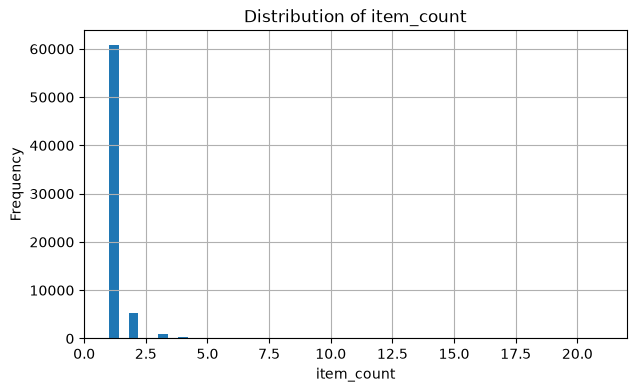

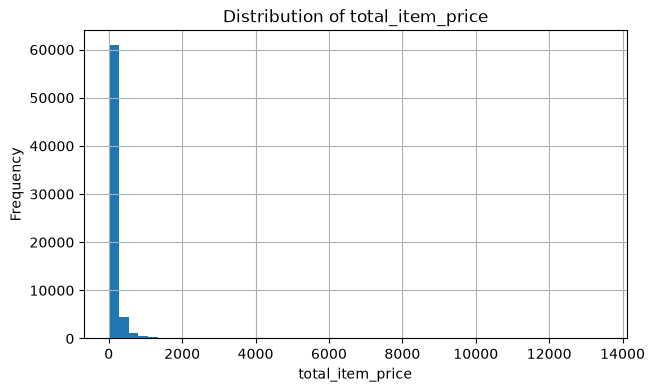

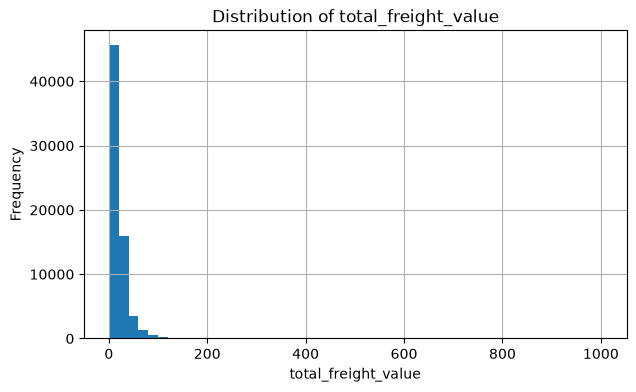

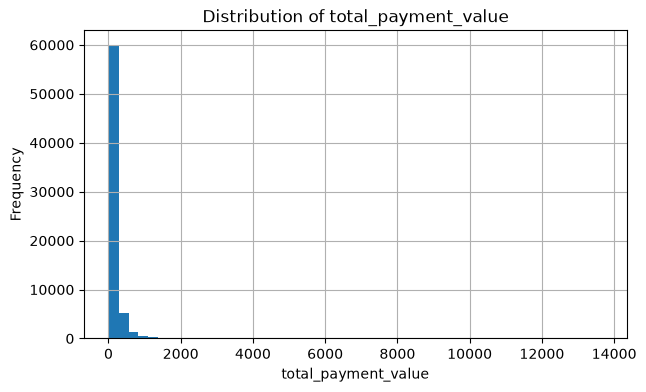

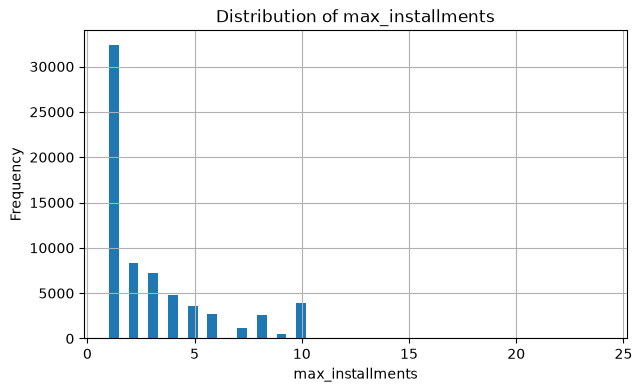

In [13]:
numeric_to_plot = [
    "item_count",
    "total_item_price",
    "total_freight_value",
    "total_payment_value",
    "max_installments"
]

for col in numeric_to_plot:
    plt.figure(figsize=(7, 4))
    train[col].hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [14]:
correlation_matrix = train[numerical_columns].corr()

display(correlation_matrix.round(2))

,customer_zip_code_prefix,item_count,total_item_price,total_freight_value,unique_products,unique_sellers,total_payment_value,payment_records,max_installments
customer_zip_code_prefix,1.00,-0.00,0.03,0.18,-0.01,-0.00,0.05,-0.01,0.05
item_count,-0.00,1.00,0.16,0.48,0.46,0.26,0.19,-0.00,0.07
total_item_price,0.03,0.16,1.00,0.41,0.06,0.04,1.00,0.00,0.31
total_freight_value,0.18,0.48,0.41,1.00,0.21,0.12,0.49,0.00,0.20
unique_products,-0.01,0.46,0.06,0.21,1.00,0.56,0.07,0.01,0.07
unique_sellers,-0.00,0.26,0.04,0.12,0.56,1.00,0.05,0.02,0.06
total_payment_value,0.05,0.19,1.00,0.49,0.07,0.05,1.00,0.00,0.32
payment_records,-0.01,-0.00,0.00,0.00,0.01,0.02,0.00,1.00,-0.04
max_installments,0.05,0.07,0.31,0.20,0.07,0.06,0.32,-0.04,1.00


In [15]:
late_rates_by_state = (
    train
    .groupby("customer_state")["label"]
    .apply(lambda x: (x == "Late").mean() * 100)
    .sort_values(ascending=False)
)

display(late_rates_by_state)

customer_state
AL    27.852349
MA    21.532847
CE    18.248945
RR    17.241379
SE    17.073171
PI    16.666667
RJ    16.583027
BA    14.997833
PA    13.370474
ES    13.287197
TO    13.197970
PB    12.702703
RN    12.320917
SC    11.951882
PE    11.906893
MS    11.752988
GO     9.581263
RS     8.665644
MT     8.593750
DF     7.977208
MG     6.297663
AP     5.882353
SP     5.594765
PR     5.431956
AM     4.761905
AC     4.545455
RO     3.783784
Name: label, dtype: float64

In [16]:
late_rates_by_payment = (
    train
    .groupby("payment_types")["label"]
    .apply(lambda x: (x == "Late").mean() * 100)
    .sort_values(ascending=False)
)

display(late_rates_by_payment)

payment_types
debit_card              9.885387
boleto                  9.409395
credit_card             8.983527
credit_card, voucher    7.706535
voucher                 7.581227
Name: label, dtype: float64

In [17]:
train["purchase_month"] = train["order_purchase_timestamp"].dt.month
train["purchase_dayofweek"] = train["order_purchase_timestamp"].dt.dayofweek
train["purchase_hour"] = train["order_purchase_timestamp"].dt.hour

train["estimated_delivery_days"] = (
    train["order_estimated_delivery_date"]
    - train["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

In [18]:
print(
    train.groupby("label")[
        [
            "total_item_price",
            "total_freight_value",
            "item_count",
            "estimated_delivery_days"
        ]
    ].mean()
)

         total_item_price  total_freight_value  item_count  \
label                                                        
Late           149.767376            25.202941    1.114319   
On-time        134.506741            21.950632    1.144834   

         estimated_delivery_days  
label                             
Late                   23.879064  
On-time                24.668566  


In [19]:
from pathlib import Path

CHARTS_DIR = ARTIFACTS_DIR / "eda_charts"
CHARTS_DIR.mkdir(exist_ok=True)

print("Charts folder:", CHARTS_DIR)

Charts folder: ..\artifacts\eda_charts


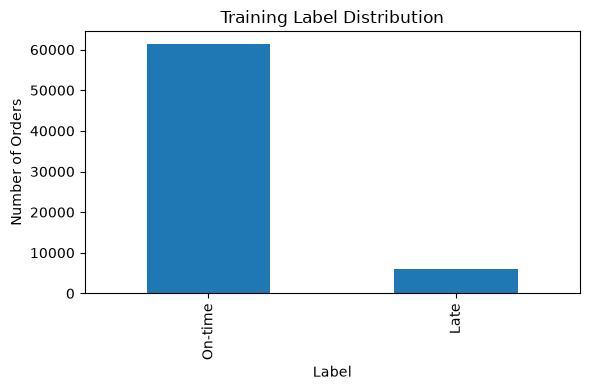

In [20]:
plt.figure(figsize=(6, 4))

train["label"].value_counts().plot(kind="bar")

plt.title("Training Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig(CHARTS_DIR / "label_distribution.png")
plt.show()

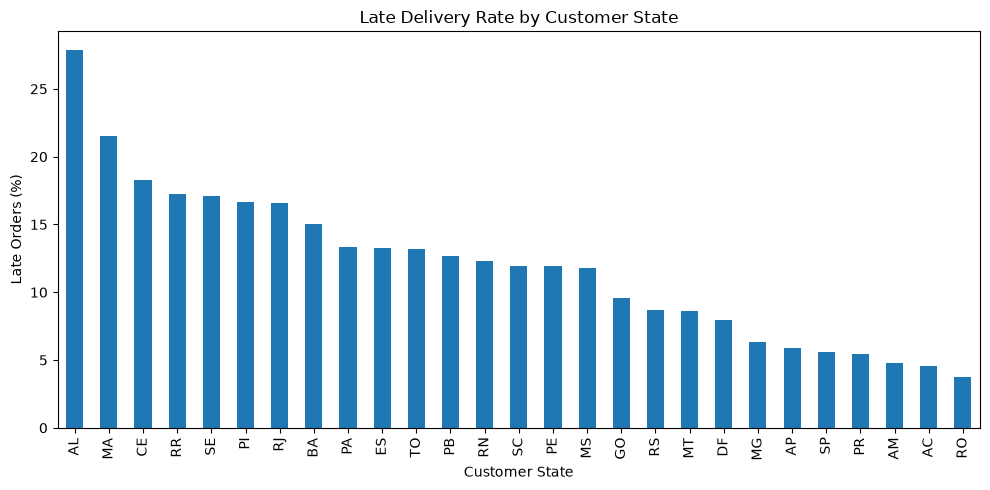

In [21]:
plt.figure(figsize=(10, 5))

late_rates_by_state.sort_values(ascending=False).plot(kind="bar")

plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Late Orders (%)")
plt.tight_layout()

plt.savefig(CHARTS_DIR / "late_rate_by_state.png")
plt.show()

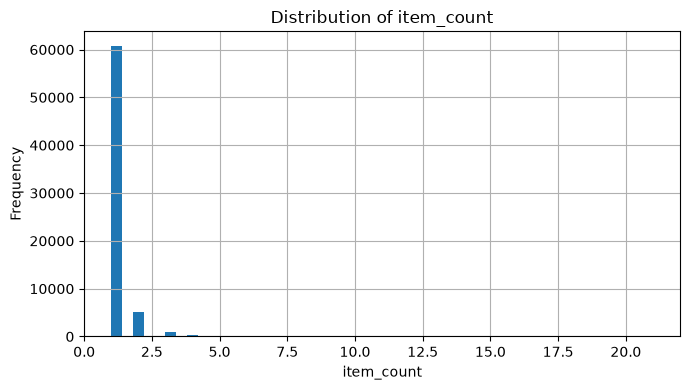

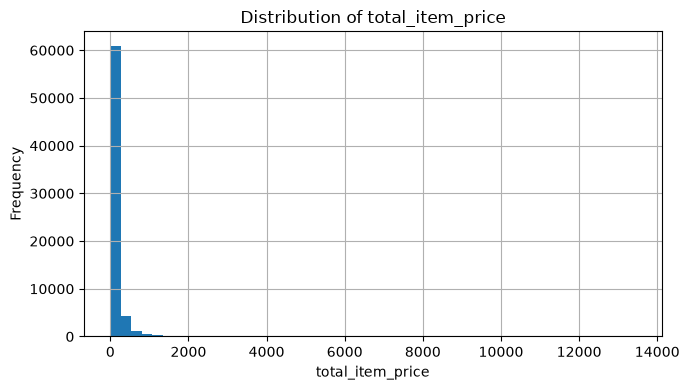

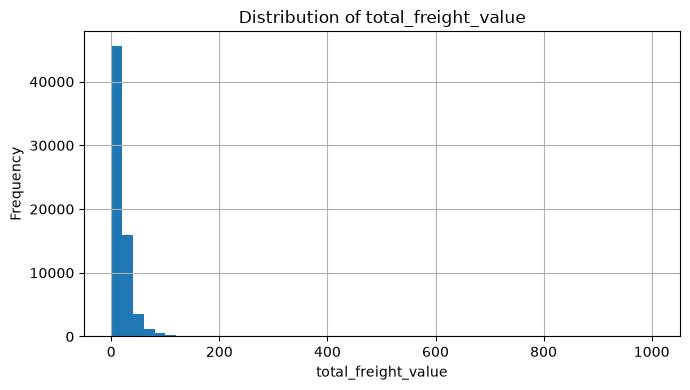

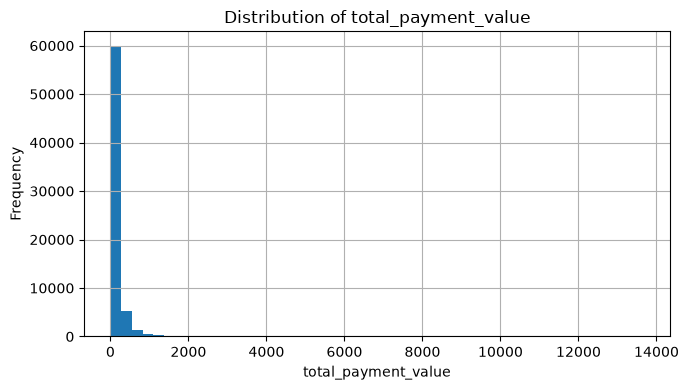

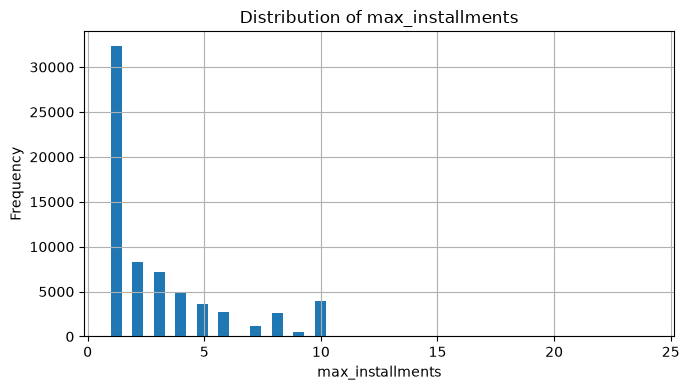

In [22]:
for col in numeric_to_plot:
    plt.figure(figsize=(7, 4))

    train[col].hist(bins=50)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()

    plt.savefig(CHARTS_DIR / f"{col}_distribution.png")
    plt.show()

## EDA Findings

- The training dataset contains 67,533 orders and 22 columns.
- The target is imbalanced: most orders are On-time, while Late orders are the minority class.
- Missing values are very limited. Payment-related fields contain only one missing observation, while `order_approved_at` has 14 missing values.
- `order_id`, `customer_id`, and `customer_unique_id` are high-cardinality identifiers and should not be used directly as model features.
- `customer_state` shows meaningful differences in late-delivery rates across geographic regions.
- `customer_city` has high cardinality (3,747 values), so direct one-hot encoding may be inefficient.
- Numerical variables such as `total_item_price`, `total_payment_value`, and `total_freight_value` are strongly right-skewed and contain large outliers.
- `total_item_price` and `total_payment_value` are almost perfectly correlated, so using both may provide redundant information.
- Late orders have slightly higher average item price and freight value.
- Late orders have a slightly shorter average estimated delivery window.
- Payment type shows relatively small differences in late-delivery rates.
- Date-derived features such as purchase month, day of week, hour, and estimated delivery window may be useful.
- Actual delivery date must not be used as a feature because it is future information and would cause target leakage.

### Prediction Point

The model will predict delivery lateness at order purchase time. Therefore, only information available at or before the prediction point should be used as model features.